## **Amazon Sales Analysis**

#### **1) Objective :-** To analyze Amazon product data using Python and identify useful patterns in product pricing, discounts, ratings, reviews, categories, and brands. The analysis aims to generate data-driven insights that can help understand customer preferences and support better product and promotional decisions.

### **2) Importing Libraries :-**

In [133]:
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

In [134]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### **3) Load Dataset :-**


In [135]:
df = pd.read_csv("/content/drive/MyDrive/amazon.csv.zip")

####**4) Dataset Overview :-**
The dataset contains 1,465 product records and 16 columns related to Amazon products. It includes information such as product name, category, discounted price, actual price, discount percentage, rating, rating count, customer reviews, and product links.

During data preprocessing, missing values were handled, and relevant columns such as prices, discount percentage, rating, and rating count were converted into appropriate numerical formats for analysis.

### **5) Data Cleaning :-**

In [137]:
## Converting the Datatype from numberic obj to float
df["discounted_price"] = df["discounted_price"].replace({"₹":"",",":""}, regex=True).astype(float)
df["actual_price"] = df["actual_price"].replace({"₹":"",",":""}, regex=True).astype(float)
df["discount_percentage"] = df["discount_percentage"].replace("%","", regex=True).astype(float)

df["rating"] = df["rating"].replace(r"|\|","", regex=True)
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df["rating_count"] = df["rating_count"].astype(str).str.replace(',', '').astype(float)

## Filling Null values
df["rating"] = df["rating"].fillna(0.0)
df = df.drop_duplicates(subset=['product_id'], keep='first')

###**6) Exploratory Data Analysis :-**

####**Analysis 1 :-** Top 10 Products with Highest Discount

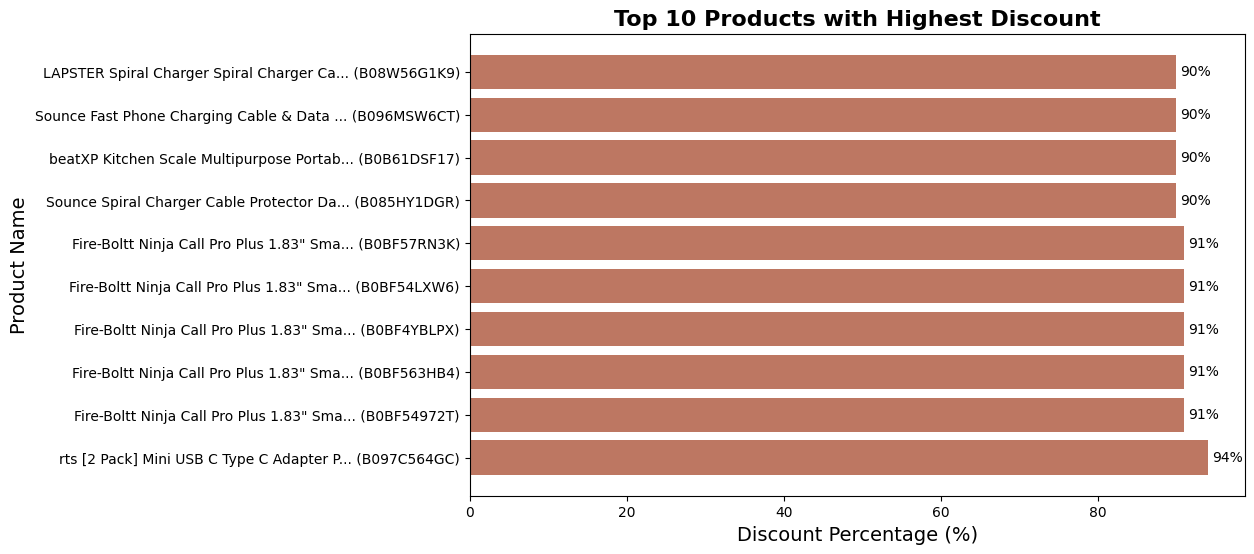

In [138]:
top_discount_products = df.sort_values("discount_percentage", ascending=False).head(10)
## creating a short usable product name
top_discount_products["short_name"] = (top_discount_products["product_name"].str[:40]+ "..."
    + " ("
    + top_discount_products["product_id"]
    + ")"
)
## To display the percentage
fig, ax = plt.subplots(figsize=(10, 6))
bars = plt.barh(top_discount_products["short_name"],top_discount_products["discount_percentage"],color="#BD7762")
ax.bar_label(bars,fmt="%.0f%%",padding=3)

plt.title("Top 10 Products with Highest Discount",fontsize=16, fontweight="bold")
plt.xlabel("Discount Percentage (%)",fontsize=14)
plt.ylabel("Product Name", fontsize=14)
plt.show()

####**Insights :-**
• The top 10 products offer discounts between **90% and 94%**, indicating aggressive promotional pricing.

• A high discount does not necessarily mean a better product. Customer ratings and review counts should also be considered.

• These products can be shortlisted for promotional campaigns after evaluating customer satisfaction.

#### **Business Recommendation :-**
 Products with high discounts should be analyzed alongside customer ratings and review counts before being featured in promotional campaigns. This helps ensure that discounted products also maintain customer trust and satisfaction, leading to better long-term sales performance.

####**Analysis 2 :-** Most popular product categories

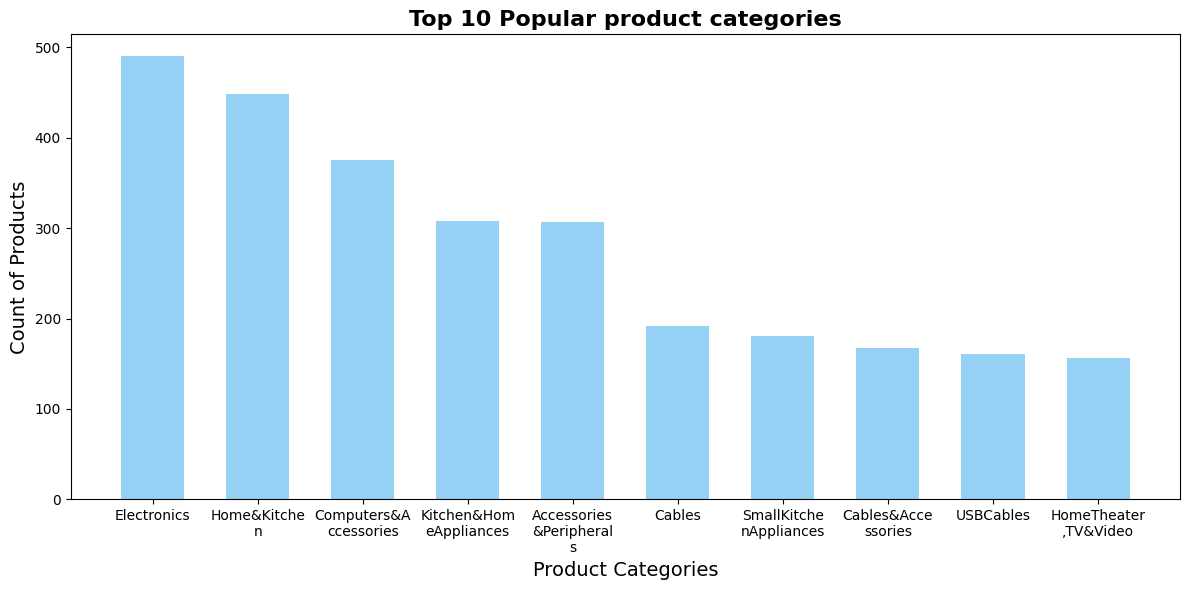

In [139]:
import textwrap
df_exploded = df.copy()
df_exploded["category"] = df["category"].str.split("|")
df_exploded = df_exploded.explode("category")
top_category = df_exploded["category"].value_counts().head(10)

plt.figure(figsize=(12, 6))
plt.bar(
    [textwrap.fill(label, width=11) for label in top_category.index],
    top_category, color="#94D1F4",width=0.6)

plt.title("Top 10 Popular product categories", fontsize=16, fontweight="bold")
plt.xlabel("Product Categories",fontsize=14)
plt.ylabel("Count of Products",fontsize=14)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### **Insights :-**
• Electronics-related categories have the highest number of products.

• Product distribution is concentrated in a few major categories.

• These categories represent Amazon's primary focus areas in the dataset.

### **Business Recommendation :-**
Increase inventory and marketing efforts for the most popular product categories, as they represent the largest share of the product catalog and are likely to attract more customers.

#### **Analysis 3 :-** Top Rated Products

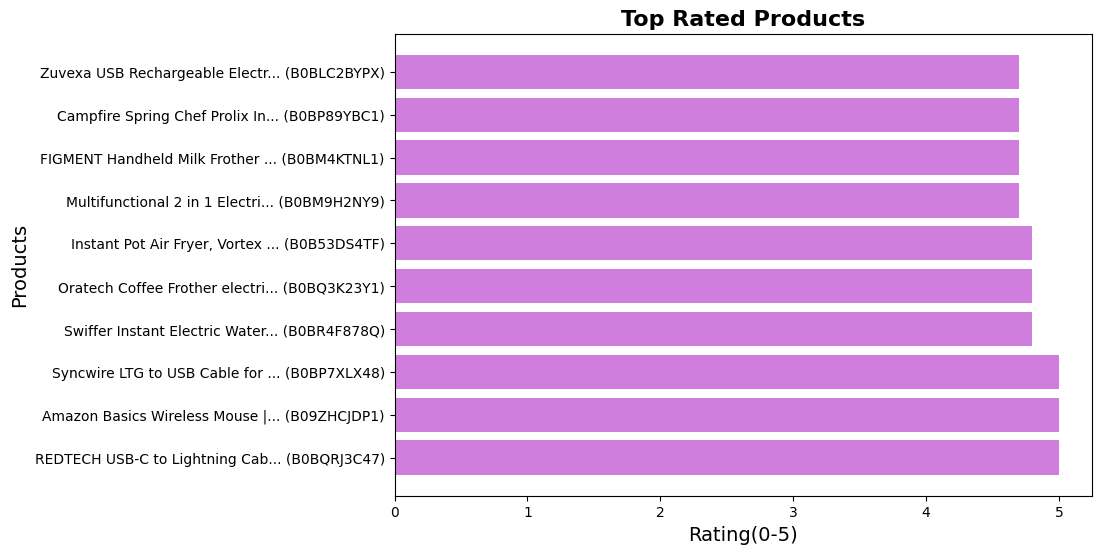

In [140]:
df_top_rated_products = df.copy()
df_top_rated_products = df.sort_values(by="rating", ascending=False).head(10)
df_top_rated_products["short_name"] = (df_top_rated_products["product_name"].str[:30]+ "..."
    + " ("
    + df_top_rated_products["product_id"]
    + ")"
)

plt.figure(figsize=(9,6))
plt.barh(df_top_rated_products["short_name"], df_top_rated_products["rating"], color="#D07EDD")
plt.title("Top Rated Products", fontsize=16, fontweight="bold")
plt.ylabel("Products",fontsize=14)
plt.xlabel("Rating(0-5)",fontsize=14)
plt.show()

####**Insights :-**


*   Most of the top-rated products belong to the Electronics category.
*   All top-rated products have ratings close to 5, indicating excellent customer satisfaction.



####**Business Recommendation :-**
 Recommend top-rated products in search results and personalized recommendations to improve customer trust and increase conversion rates.

####**Analysis 4 :-** Most Reviewed Products

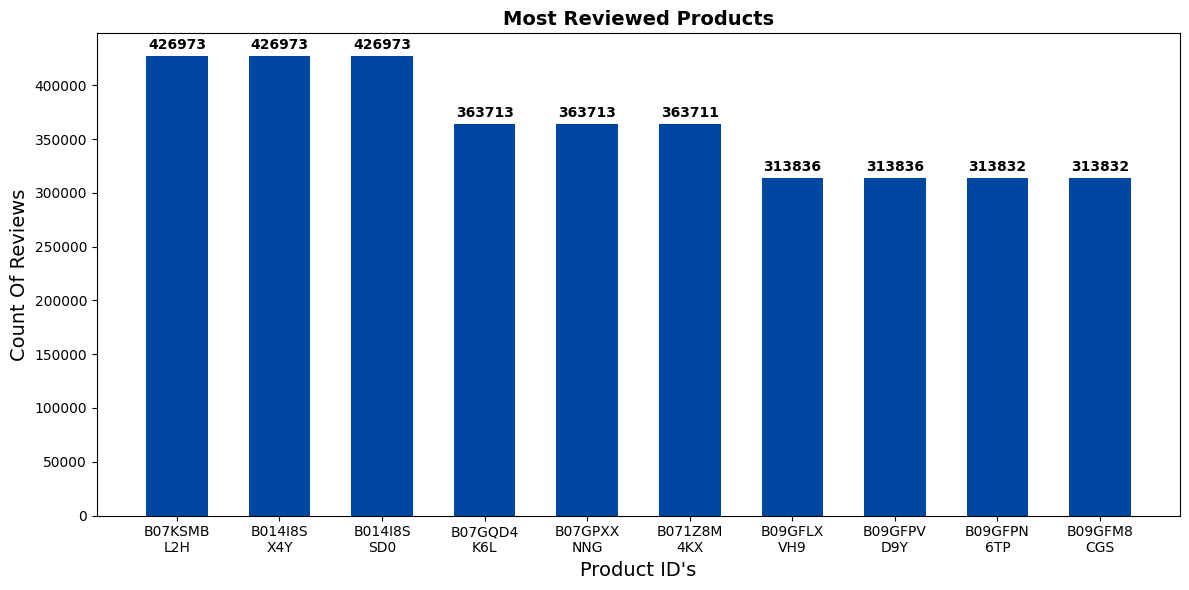

In [141]:
## Creating df with Most reviewed product
df_products = df.copy()
df_products = df.sort_values(by="rating_count", ascending=False).head(10)

df_products["short_name"] = (df_products["product_name"].str[:40])


plt.figure(figsize=(12,6))
plt.title("Most Reviewed Products",fontsize=14, fontweight="bold")
bars = plt.bar(
  [textwrap.fill(label, width=7) for label in df_products["product_id"]],
  df_products["rating_count"],
  width=0.6,
  color="#0047A3"
)

ax = plt.gca()
ax.bar_label(bars, padding=3, fontweight="bold")

plt.xlabel("Product ID's",fontsize=14)
plt.ylabel("Count Of Reviews",fontsize=14)
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

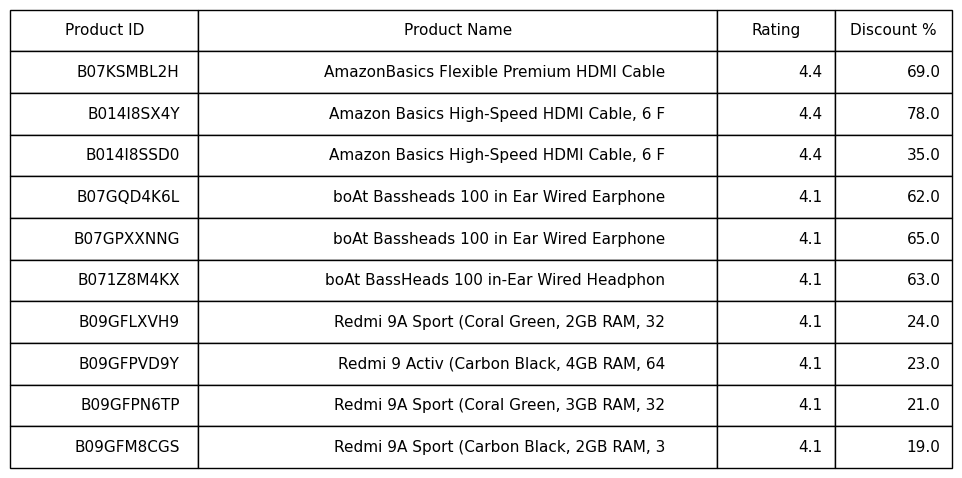

In [142]:
## Creating table to recognize Products by their ID
plt.figure(figsize=(10,6))
fig, ax = plt.subplots()
ax.axis("off")

table = plt.table(
  cellText=df_products[["product_id", "short_name","rating","discount_percentage"]].values,
  colLabels=["Product ID", "Product Name", "Rating", "Discount %"],
  loc="center",
  colWidths=[0.2,0.55,0.125,0.125])

table.scale(1.9,2.5)
table.set_fontsize(11)
table.auto_set_font_size(False)
plt.show()

####**Insights :-**


*   The most-reviewed products do not necessarily have the highest ratings.
*   The products with the highest number of reviews do not necessarily have the highest ratings.


####**Analysis 5 :-** Categories with Highest Average Discount

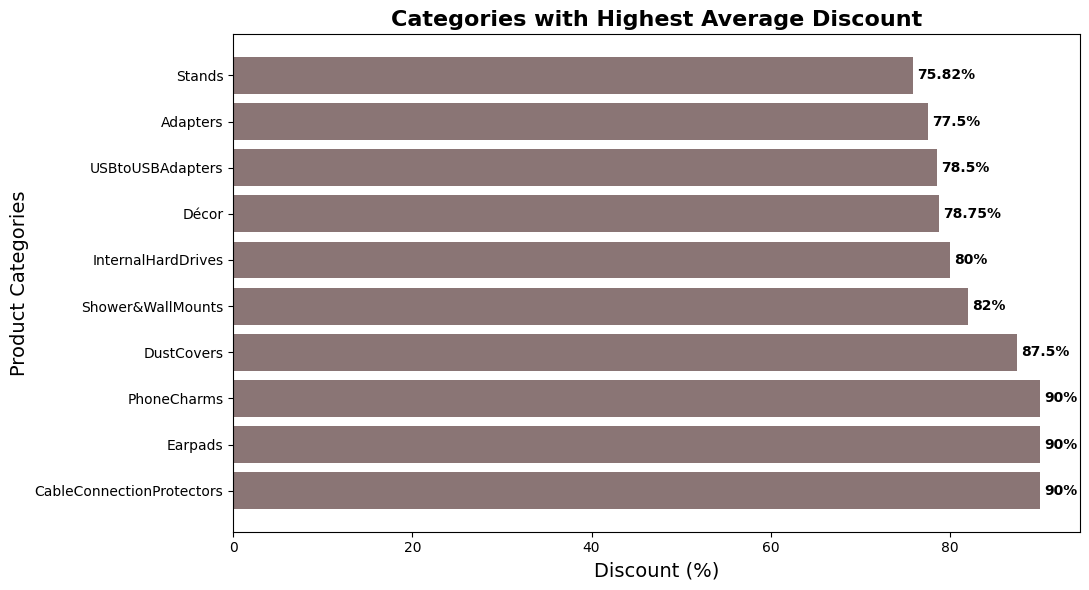

In [143]:
products = df_exploded.groupby(df_exploded["category"])["discount_percentage"].mean().round(2).sort_values(ascending=False).head(10)

plt.figure(figsize=(11,6))
plt.title("Categories with Highest Average Discount",fontsize=16,fontweight="bold")
bars = plt.barh(products.index,products,color="#8A7575")

ax = plt.gca()
ax.bar_label(bars, padding=3,fontweight="bold",fmt='%g%%')

plt.ylabel("Product Categories",fontsize=14)
plt.xlabel("Discount (%)",fontsize=14)
plt.tight_layout()
plt.show()

#### **Insights :-**
• PhoneCharms, Earpads, and CableConnectionProtectors have the highest average discounts at around **90%**.

• The top 10 categories have average discounts ranging from approximately **76% to 90%**.

• Some smaller product categories receive substantially higher discounts than others.


#### **Business Recommendation :-** Review highly discounted categories to determine whether these discounts are driving customer demand while maintaining healthy margins.


####**Analysis 6 :-** Top 10 Best Value Products

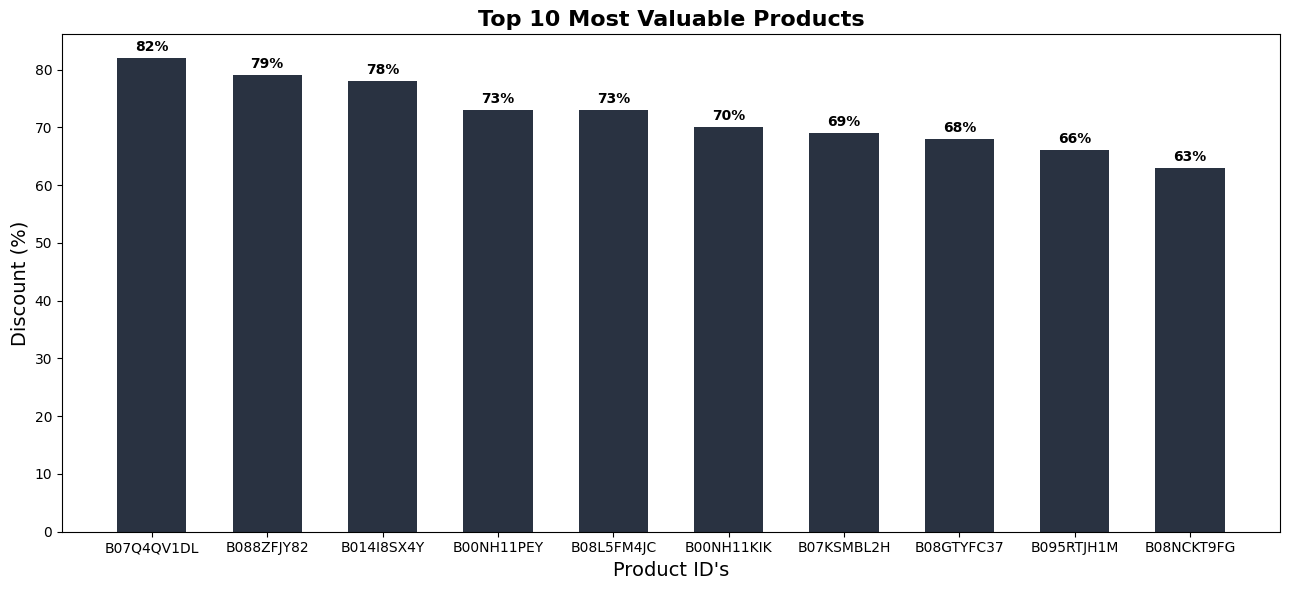

In [144]:
df_valueProducts = df[["product_id","product_name","discount_percentage","rating","rating_count"]]
condition = ((df_valueProducts["rating"] > 4.3) & (df_valueProducts["rating_count"] > 20000))
df_valueProducts = df_valueProducts[condition]
df_valueProducts = df_valueProducts.sort_values(by="discount_percentage", ascending=False).head(10)

plt.figure(figsize=(13,6))
plt.title("Top 10 Most Valuable Products",fontsize=16,fontweight="bold")
bars = plt.bar(df_valueProducts["product_id"], df_valueProducts["discount_percentage"],color="#293241",width=0.6)

ax = plt.gca()
ax.bar_label(bars, padding=3,fontweight="bold",fmt="%g%%")

plt.ylabel("Discount (%)",fontsize=14)
plt.xlabel("Product ID's",fontsize=14)
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

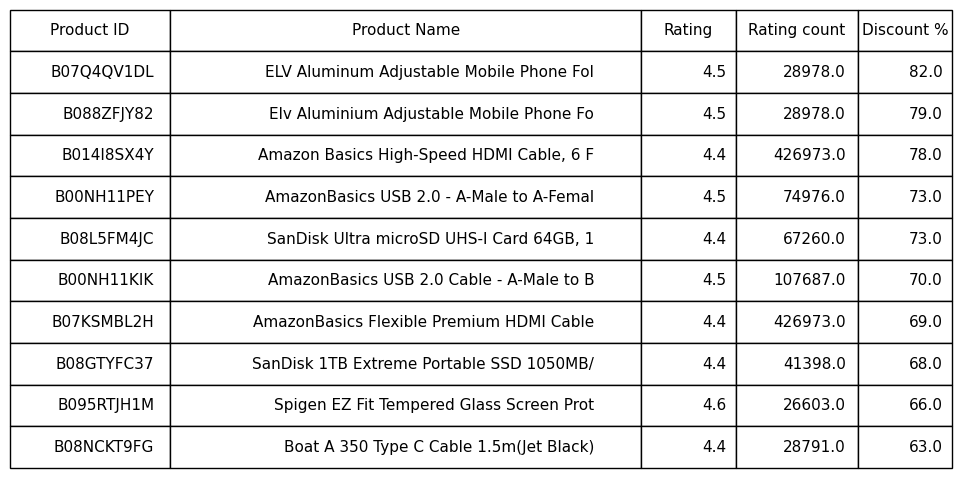

In [145]:
df_valueProducts["short_name"] = (df_valueProducts["product_name"].str[:40])

plt.figure(figsize=(10,6))
fig, ax = plt.subplots()
ax.axis("off")

table = plt.table(
  cellText=df_valueProducts[["product_id", "short_name","rating","rating_count","discount_percentage"]].values,
  colLabels=["Product ID", "Product Name", "Rating","Rating count", "Discount %"],
  loc="center",
  colWidths=[0.17,0.5,0.1,0.13,0.1])

table.scale(1.9,2.5)
table.set_fontsize(11)
table.auto_set_font_size(False)
plt.show()

#### **Insights :-**
• All selected products have high ratings of **4.4 or above**, indicating strong customer satisfaction.

• The products offer discounts ranging from **63% to 82%**, while also having a substantial number of customer reviews.

• Products with both high ratings and high review counts can be considered strong candidates for customers looking for value.


####**Business Recommendation :-**
Prioritize these products in recommendations and promotional campaigns, as they combine high customer satisfaction, strong customer engagement, and significant discounts.

#### **Analysis 7 :-** Discount vs Rating

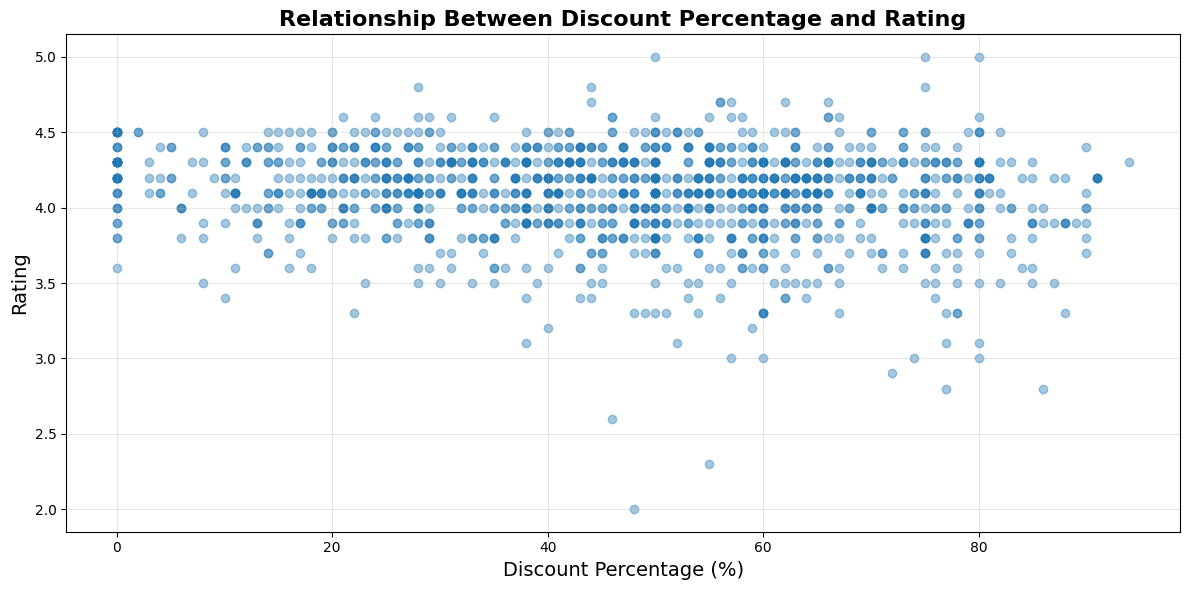

In [153]:
df_DvsR = df[df["rating"] > 0]
plt.figure(figsize=(12,6))
plt.grid()
plt.scatter(df_DvsR["discount_percentage"],df_DvsR["rating"],alpha=0.4)
plt.xlabel("Discount Percentage (%)",fontsize=14)
plt.ylabel("Rating",fontsize=14)
plt.title("Relationship Between Discount Percentage and Rating",fontsize=16,fontweight="bold")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### **Insight :-**

• There is **no clear relationship** between discount percentage and customer rating.

• Most products have ratings between approximately **4.0 and 4.4**, regardless of their discount percentage.

• Higher discounts do not necessarily correspond to higher customer ratings.


#### **Business Recommendation :-**
Do not rely on discount percentage alone when evaluating products for promotion; consider customer ratings and review counts alongside discounts.


####**Analysis 8 :-** Product Price Distribution

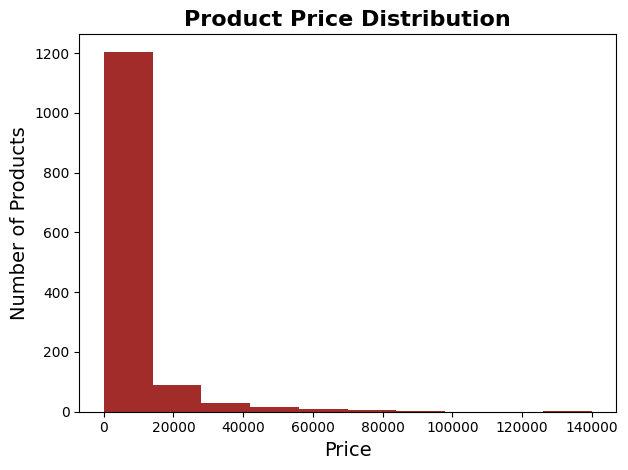

In [152]:
bars = plt.hist(df["actual_price"],color="#a22c29")
plt.title("Product Price Distribution",fontsize=16,fontweight="bold")
plt.xlabel("Price",fontsize=14)
plt.ylabel("Number of Products",fontsize=14)
plt.tight_layout()
plt.show()

####**Insight :-**
• The product price distribution is strongly **right-skewed**, with most products concentrated in the lower price range.

• Only a small number of products have very high prices, extending up to approximately **₹140,000**.

• The large difference between common and extreme prices indicates significant variation in product pricing.


#### **Business Recommendation :-**

Use different pricing and promotional strategies for lower-priced products and premium high-priced products rather than applying a single pricing strategy across all products.


#### **Analysis 9 :-** Most Popular Brands

**Important :-** Brand names were approximated by extracting the first word from the product name, as the dataset does not contain a dedicated brand column.

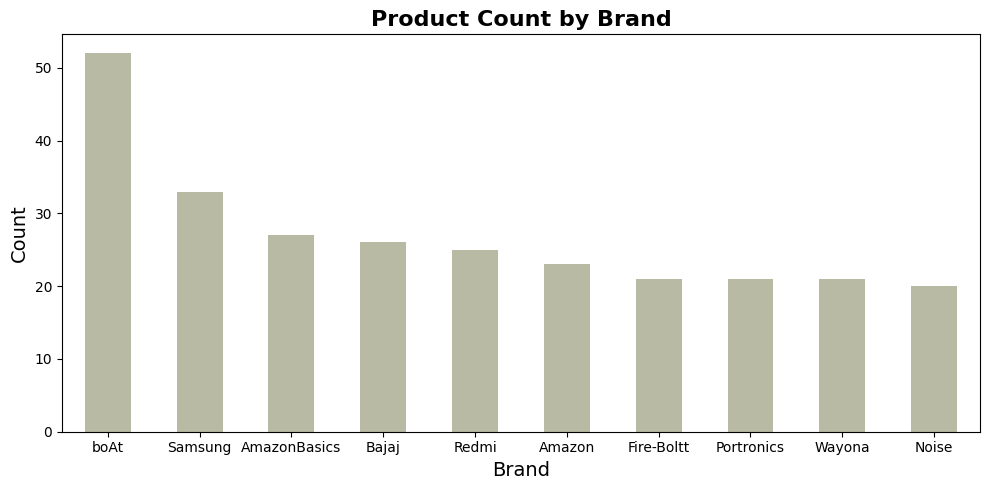

In [148]:
df["brand"] = df["product_name"].str.split().str[0]

plt.figure(figsize=(10,5))
df["brand"].value_counts().head(10).plot(kind="bar",color="#b9baa3")

plt.title("Product Count by Brand", fontsize=16, fontweight="bold")
plt.xlabel("Brand", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### **Insight :-**
• **boAt** has the highest number of products in the dataset, with more than 50 products.

• **Samsung** ranks second, followed by **AmazonBasics** and **Bajaj**.

• The product catalog is concentrated among a few leading brands, while the remaining brands have a relatively similar product count.


####**Analysis 10:-** Best Value vs Premium Products

In [149]:
condition = ((df["rating"] >= 4.3) & (df["rating_count"] > 20000) & (df["discount_percentage"] > 50))
df_valProd = df[condition]

condition = ((df["rating"] >= 4.3) & (df["rating_count"] > 20000) & (df["actual_price"] > 10000))
df_premiumProd = df[condition]

print("====Average====\n")
print("---High-Value Products---")
print(df_valProd[["rating", "discount_percentage", "actual_price", "rating_count"]].mean().round(2))

print("\n---Premium Products---")
print(df_premiumProd[["rating", "discount_percentage", "actual_price", "rating_count"]].mean().round(2))

====Average====

---High-Value Products---
rating                     4.36
discount_percentage       67.00
actual_price            2912.97
rating_count           74303.72
dtype: float64

---Premium Products---
rating                     4.33
discount_percentage       32.83
actual_price           39499.17
rating_count           26478.67
dtype: float64


#### **Insight :-**
• High-value products have a higher average discount of **67%**, while premium products have an average discount of **32.83%**.

• Premium products have a much higher average actual price of approximately **₹39,499**, compared with **₹2,913** for high-value products.

• Both groups have similar average ratings, around **4.3**, indicating that higher-priced products can maintain strong customer ratings.


###**7) Business Questions :-**
*   Which product categories have the most products?
*   Which products have the highest ratings?
*   Does a higher discount lead to higher ratings?
*   How are product prices distributed?
*   Which products offer the best combination of rating, reviews, and discount?
*   How do high-value products compare with premium products?
*   Which categories offer the highest average discounts?
*   Which brands have the most products?



###**8) Key Findings :-**
* Products with higher discounts do not necessarily have higher ratings.
* The product price distribution is strongly right-skewed.
boAt has the highest product count among the extracted brands.
* High-value products have a much higher average discount than premium products.
* Premium products have a much higher average actual price while maintaining ratings above 4.3.

###**9) Conclusions :-**
This analysis provided insights into product pricing, discounts, ratings, reviews, categories, and brands. The analysis shows that higher discounts do not necessarily result in higher customer ratings. High-value products offer substantial discounts while premium products have significantly higher prices with similar customer ratings. These findings can help businesses improve product recommendations, pricing strategies, and promotional decisions.

###**10) Future Improvements :-**
* Perform deeper analysis using customer review text.
* Analyze relationships between price, discount, rating, and review count using statistical methods.
* Create an interactive dashboard using Power BI or Tableau.
* Perform brand-level and category-level comparisons in greater detail.